In [10]:
# ─────────────────────────────────────────────
# [C1] ⚙️ 데이터 준비
# 최초 1회 다운로드 → data/ 폴더에 저장 (이후 오프라인)
# ─────────────────────────────────────────────
import urllib.request, zipfile
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import matplotlib.font_manager as fm
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

system = platform.system()
if system == "Darwin":                      # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                                        # 코랩 등 리눅스 — 나눔고딕을 설치해야 합니다
    if not any("Nanum" in f.name for f in fm.fontManager.ttflist):
        print("나눔고딕을 설치합니다 (10~20초 걸립니다)...")
        import subprocess
        subprocess.run("apt-get install -y -qq fonts-nanum", shell=True,
                       capture_output=True)
        for path in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
            fm.fontManager.addfont(path)
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def fetch_uci(url, zip_name, member):
    """UCI 정적 저장소의 zip을 내려받아 data/에 풀고, CSV 경로를 돌려줍니다."""
    csv_path = DATA_DIR / member
    if not csv_path.exists():
        zip_path = DATA_DIR / zip_name
        if not zip_path.exists():
            print(f"내려받는 중… {zip_name}")
            urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extract(member, DATA_DIR)
    return csv_path

shoppers = pd.read_csv(fetch_uci(
    "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip",
    "online_shoppers.zip", "online_shoppers_intention.csv"))

NUM_COLS = ["Administrative", "Administrative_Duration", "Informational",
            "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
            "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

X = shoppers[NUM_COLS]
y = shoppers["Revenue"].astype(int)

print(f"쇼핑 세션 데이터: {shoppers.shape[0]:,}행 × {shoppers.shape[1]}열")
print(f"구매 전환율: {y.mean():.4f}")
print("\n→ 준비 완료. 이제 여러분 차례입니다.")

쇼핑 세션 데이터: 12,330행 × 18열
구매 전환율: 0.1547

→ 준비 완료. 이제 여러분 차례입니다.


In [11]:
# [C2] 문제 1. 교차 검증으로 다섯 모델을 다시 잰다
# ⌨️ 문제 1 — 홀드아웃과 계층 5겹 교차 검증을 나란히
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# 여기에 코드를 작성하세요 (분리 → 모델별 홀드아웃·CV → 비교표)

# 1) 8:2 홀드아웃 분리 (class 비율 유지 위해 stratify 권장)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

models = {
    "Dummy": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "Tree(기본)": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Tree(max_depth=5)": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []
for name, model in models.items():
    # 홀드아웃 학습 및 평가
    model.fit(X_train, y_train)
    holdout_acc = accuracy_score(y_test, model.predict(X_test))

    # 교차 검증 (전체 X, y 사용 — 데이터 누수 방지 위해 매 fold마다 새로 학습됨)
    cv_scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()

    results.append({
        "모델": name,
        "홀드아웃": holdout_acc,
        "CV 평균": cv_mean,
        "CV 표준편차": cv_std,
        "차이(홀드아웃-CV평균)": holdout_acc - cv_mean,
    })

# ─────────────────────────────────────────────
# [C4] 결과 표 정리
# ─────────────────────────────────────────────
results_df = pd.DataFrame(results).set_index("모델")
results_df = results_df.round(4)
print(results_df)

results_df.to_csv("model_comparison_v3.csv", encoding="utf-8-sig")
print("저장 완료: model_comparison_v3.csv")

                     홀드아웃   CV 평균  CV 표준편차  차이(홀드아웃-CV평균)
모델                                                       
Dummy              0.8451  0.8453   0.0002        -0.0002
Tree(기본)           0.8423  0.8537   0.0017        -0.0114
Tree(max_depth=5)  0.8942  0.8913   0.0040         0.0028
RandomForest       0.8946  0.8928   0.0049         0.0018
XGBoost            0.8889  0.8890   0.0041        -0.0001
저장 완료: model_comparison_v3.csv


1. 차이와 cv 표준편차의 관계(절대값 기준)
  - 차이 < cv 표준편차 : 홀드아웃 정확도가 cv 표준편차 범위 안에 있다는 뜻, 그냥 우연
  - 차이 > cv 표준편차 : 홀드아웃 test set이 유난히 어렵거나 어려웠을 가능성

2. 결과해석
  - 트리모델을 보면 표준편차가 차이에 비해 6.7배 높다. 홀드아웃 test set이 모델기준으로 어려웠거나 트리 자체가 분할마다 성능이 바뀔수있음 - 과적합의심

In [12]:
# [C3] 문제 2. 분할 운의 폭을 직접 잰다
# ⌨️ 문제 2 — random_state만 바꿔 10번 재기

# 여기에 코드를 작성하세요 (시드 10개 × 두 모델 → 최소·최대·폭·평균±표준편차)

# 모델을 매번 새로 만들기 위한 factory 함수
model_factories = {
    "Tree(max_depth=5)": lambda: DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "RandomForest": lambda: RandomForestClassifier(random_state=RANDOM_STATE),
}

scores = {name: [] for name in model_factories}

for seed in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    for name, factory in model_factories.items():
        model = factory()  # 매번 새 객체 생성
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        scores[name].append(acc)

summary = []
for name, score_list in scores.items():
    arr = np.array(score_list)
    summary.append({
        "모델": name,
        "최소": arr.min(),
        "최대": arr.max(),
        "폭(최대-최소)": arr.max() - arr.min(),
        "평균": arr.mean(),
        "표준편차": arr.std(),
    })

summary_df = pd.DataFrame(summary).set_index("모델").round(4)
print(summary_df)

                       최소      최대  폭(최대-최소)      평균    표준편차
모델                                                         
Tree(max_depth=5)  0.8848  0.8986    0.0138  0.8918  0.0037
RandomForest       0.8897  0.9027    0.0130  0.8960  0.0037


- 소수점 셋째자리는 보통 쓸모없음, 여기서 중요한건 **폭이 0.01**이라는 것.
- 트리와 랜덤포레스트의 최대 최소값을 확인할 수 있음

   표본 크기   학습 점수   검증 점수  격차(학습-검증)
0    986  1.0000  0.8930     0.1070
1   2761  1.0000  0.8946     0.1054
2   4537  1.0000  0.8955     0.1045
3   6312  0.9997  0.8951     0.1047
4   8088  0.9997  0.8953     0.1044
5   9864  0.9996  0.8928     0.1068


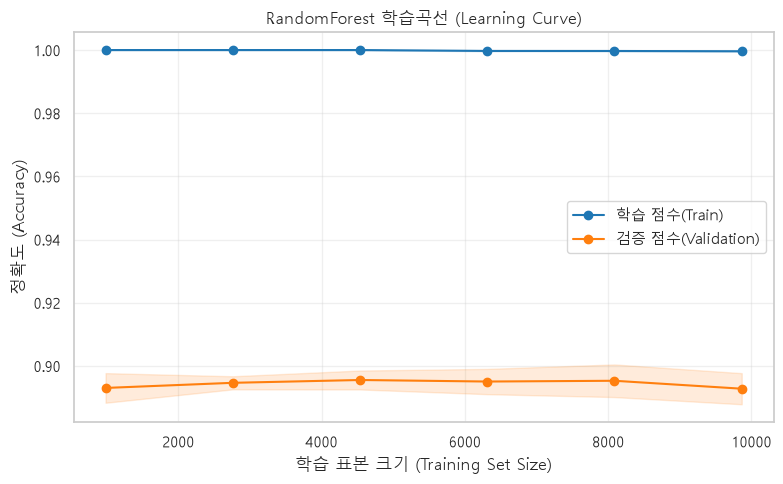

In [13]:
# [C4] 문제 3. 학습곡선 — 데이터를 더 모을까, 모델을 바꿀까
# ⌨️ 문제 3 — 학습곡선으로 다음 투자를 정하기
from sklearn.model_selection import learning_curve

# 여기에 코드를 작성하세요 (learning_curve → 표본별 표 → 두 곡선 그래프)

rf_for_lc = RandomForestClassifier(random_state=RANDOM_STATE)

train_sizes, train_scores, valid_scores = learning_curve(
    rf_for_lc, X, y,
    cv=skf,  # 문제 1의 StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_sizes=np.linspace(0.1, 1.0, 6),
    scoring="accuracy",
    n_jobs=-1,
)

# 겹 방향(axis=1)으로 평균/표준편차 계산
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
valid_mean = valid_scores.mean(axis=1)
valid_std = valid_scores.std(axis=1)

lc_df = pd.DataFrame({
    "표본 크기": train_sizes,
    "학습 점수": train_mean,
    "검증 점수": valid_mean,
    "격차(학습-검증)": train_mean - valid_mean,
}).round(4)

print(lc_df)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, "o-", color="tab:blue", label="학습 점수(Train)")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                  alpha=0.15, color="tab:blue")

plt.plot(train_sizes, valid_mean, "o-", color="tab:orange", label="검증 점수(Validation)")
plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std,
                  alpha=0.15, color="tab:orange")

plt.xlabel("학습 표본 크기 (Training Set Size)")
plt.ylabel("정확도 (Accuracy)")
plt.title("RandomForest 학습곡선 (Learning Curve)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

1. 학습 곡선 해석
  - 이미 처음 표본 크기부터 격차가 좁혀지지 않고 있다.
  데이터가 부족해서가 아닌 모델 자체가 규제 없이 과적합하도록 설계 되어있다는 뜻
  **편향이 아닌 분산의 문제**
  모델을 규제(max_depth 제한, min_samples_leaf 늘리기 등)하는 게 먼저 필요하다

In [14]:
# [C5] 문제 4. 복잡도 조정으로 격차를 줄인다
# ⌨️ 문제 4 — 교차 검증으로 복잡도 손잡이 고르기

# 여기에 코드를 작성하세요 (max_depth CV 표 → min_samples_leaf CV·격차 표)
depth_candidates = [2, 3, 5, 8, 12, None]

depth_results = []
for depth in depth_candidates:
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
    depth_results.append({
        "max_depth": depth if depth is not None else "None(무제한)",
        "CV 평균": cv_scores.mean(),
        "CV 표준편차": cv_scores.std(),
    })

depth_df = pd.DataFrame(depth_results).round(4)
print("=== Tree max_depth 훑기 ===")
print(depth_df)

# CV 평균이 가장 높은 행 찾기
best_depth_row = depth_df.loc[depth_df["CV 평균"].idxmax()]
print(f"\nCV 기준 최적 max_depth: {best_depth_row['max_depth']} (CV 평균={best_depth_row['CV 평균']})")

leaf_candidates = [1, 5, 20, 50]

leaf_results = []
for leaf in leaf_candidates:
    # (a) 교차검증으로 일반화 성능 측정 (전체 X, y 사용)
    cv_model = RandomForestClassifier(min_samples_leaf=leaf, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(cv_model, X, y, cv=skf, scoring="accuracy")

    # (b) 학습-테스트 격차 측정을 위해 홀드아웃 분할에 별도로 fit
    #     (앞서 만든 X_train, X_test, y_train, y_test 재사용)
    gap_model = RandomForestClassifier(min_samples_leaf=leaf, random_state=RANDOM_STATE)
    gap_model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, gap_model.predict(X_train))
    test_acc = accuracy_score(y_test, gap_model.predict(X_test))

    leaf_results.append({
        "min_samples_leaf": leaf,
        "CV 평균": cv_scores.mean(),
        "CV 표준편차": cv_scores.std(),
        "학습 점수": train_acc,
        "테스트 점수": test_acc,
        "격차(학습-테스트)": train_acc - test_acc,
    })

leaf_df = pd.DataFrame(leaf_results).round(4)
print("\n=== RandomForest min_samples_leaf 훑기 ===")
print(leaf_df)

best_leaf_row = leaf_df.loc[leaf_df["CV 평균"].idxmax()]
print(f"\nCV 기준 최적 min_samples_leaf: {best_leaf_row['min_samples_leaf']} (CV 평균={best_leaf_row['CV 평균']})")

# ─────────────────────────────────────────────
# [C5-저장] 문제 4 결과 저장: 하이퍼파라미터 훑기 (depth + leaf)
# ─────────────────────────────────────────────
# depth_df와 leaf_df는 컬럼 구성이 달라서, 어느 표에서 나온 행인지
# 구분할 수 있게 "구분" 컬럼을 추가한 뒤 하나의 파일에 이어 붙입니다.
depth_df_labeled = depth_df.copy()
depth_df_labeled.insert(0, "구분", "Tree_max_depth")

leaf_df_labeled = leaf_df.copy()
leaf_df_labeled.insert(0, "구분", "RandomForest_min_samples_leaf")

hyperparam_df = pd.concat([depth_df_labeled, leaf_df_labeled], ignore_index=True)
hyperparam_df.to_csv("hyperparameter_tuning_v3.csv", index=False, encoding="utf-8-sig")
print("저장 완료: hyperparameter_tuning_v3.csv")

=== Tree max_depth 훑기 ===
   max_depth   CV 평균  CV 표준편차
0          2  0.8867   0.0077
1          3  0.8879   0.0030
2          5  0.8913   0.0040
3          8  0.8874   0.0026
4         12  0.8773   0.0023
5  None(무제한)  0.8537   0.0017

CV 기준 최적 max_depth: 5 (CV 평균=0.8913)

=== RandomForest min_samples_leaf 훑기 ===
   min_samples_leaf   CV 평균  CV 표준편차   학습 점수  테스트 점수  격차(학습-테스트)
0                 1  0.8928   0.0049  0.9998  0.9011      0.0987
1                 5  0.8957   0.0043  0.9515  0.8994      0.0521
2                20  0.8972   0.0031  0.9183  0.9019      0.0164
3                50  0.8979   0.0045  0.9055  0.8990      0.0065

CV 기준 최적 min_samples_leaf: 50.0 (CV 평균=0.8979)
저장 완료: hyperparameter_tuning_v3.csv


1. 결정트리
  - max_depth = 5에서 가장 좋은 성능을 보였음
  규제가 없을때는 (None) 다 외워버리기 때문에 오히려 성능이 낮아짐 - 분산이 커지고 노이즈까지 전부 학습해버림
  깊이가 5일때는 노이즈에 반응할 여유가 없기 때문에 새로운 데이터에는 오히려 규제가 없을때보다 잘 맞게됨
  하지만 깊이가 3일때나 8일때나 cv 평균, 표준편차가 둘다 비슷하기 때문에
  **3~8구간이면 비슷하다**라고 해석하는것이 맞다

2. 랜덤포레스트
  - 잎이 1개일때는 그냥 전부 외워버려서 학습점수가 거의 1에 가깝지만 정작 테스트 점수는 낮고 격차가 0.09다
  하지만 50개일때는 격차도 굉장히 작고 학습점수와 테스트점수 모두 꽤 일관된것을 확인할 수 있다
  이러면 노이즈에 덜 민감해진다